In [126]:
import numpy as np
import matplotlib.pyplot as plt

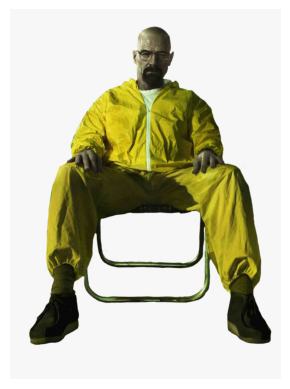

In [127]:
img1_path = 'walt.jpg'
img2_path = 'beach.jpg'
img1_raw = plt.imread(img1_path)
img2_raw = plt.imread(img2_path)
plt.axis('off')
plt.imshow(img1_raw)

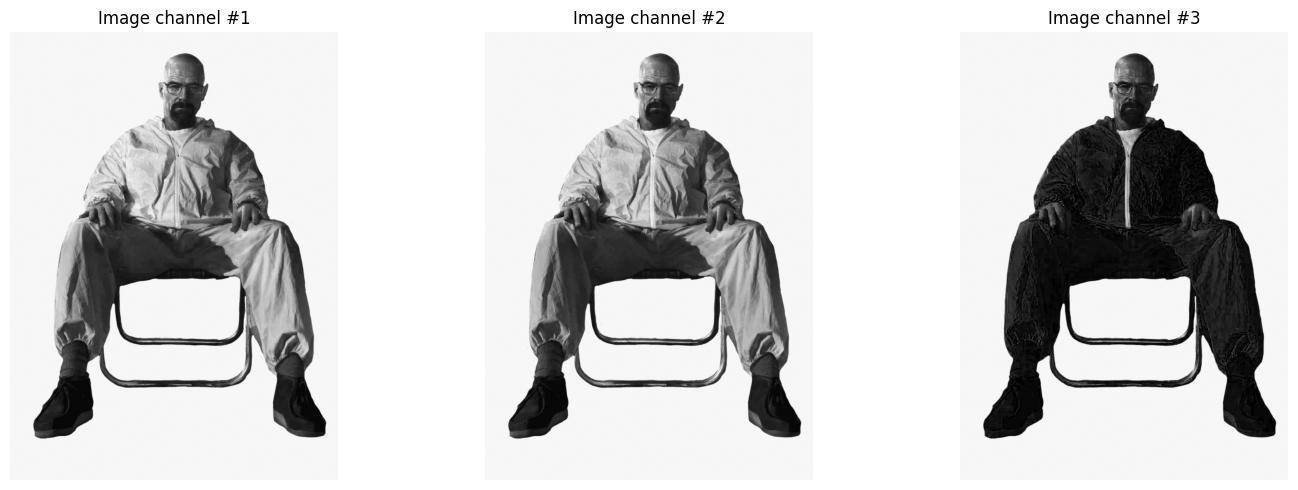

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(img1_raw[:, :, i], cmap='gray')
    axes[i].set_title(f'Image channel #{i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Image Preprocessing
---

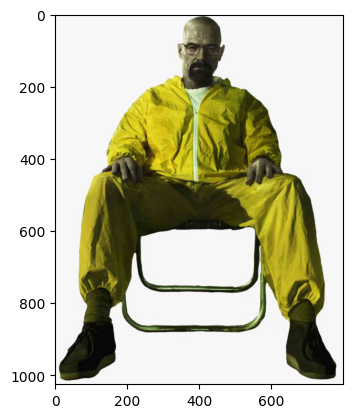

In [129]:
### Crop the image
img1 = img1_raw[50:1075, 50:850, :]
plt.imshow(img1, cmap='gray')

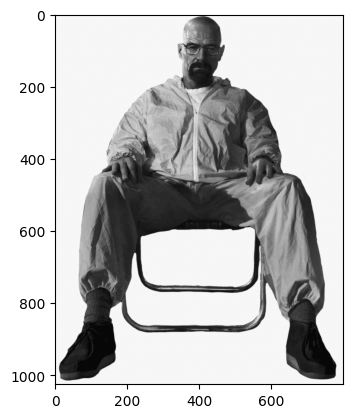

In [130]:
### Color to Grayscale
def rgb2gray_1(img):
    return 0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]

img_gray = rgb2gray_1(img1)
plt.imshow(img_gray, cmap='gray')

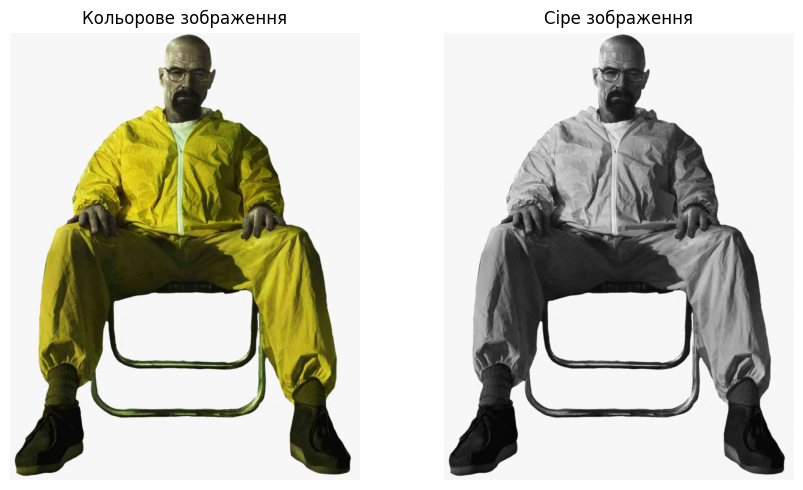

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

axes[0].imshow(img1)
axes[0].set_title('Кольорове зображення')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Сіре зображення')
axes[1].axis('off')

plt.tight_layout()
plt.show()

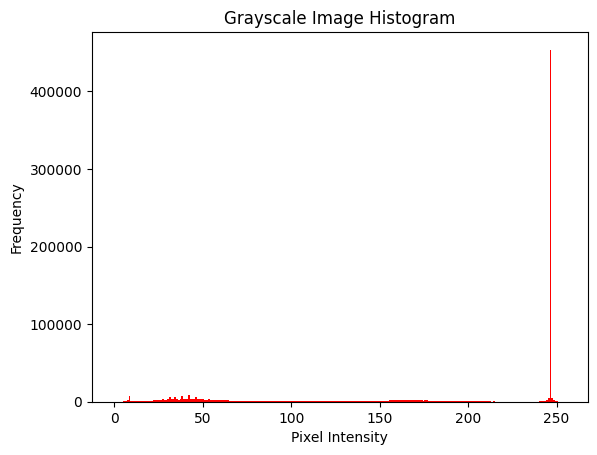

In [132]:
plt.hist(img_gray.ravel(), bins=256, range=(0, 255), color='red')
plt.title('Grayscale Image Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

### Binarization (Global Thresholding)
---

Otsu threshold = 148.9011240234375


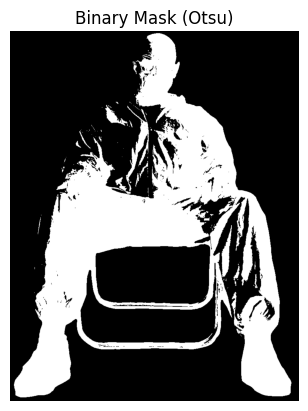

In [133]:
def otsu_threshold(gray, nbins=256):
    pixels = gray.ravel()
    if pixels.size == 0:
        raise ValueError("Порожнє зображення.")
    vmin, vmax = pixels.min(), pixels.max()
    if vmin == vmax:
        return vmin 

    hist, bin_edges = np.histogram(pixels, bins=nbins, range=(vmin, vmax))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    total = pixels.size
    sum_total = np.dot(bin_centers, hist) 

    wB = 0.0
    sumB = 0.0
    current_max = 0.0
    threshold = bin_centers[0]

    for i in range(nbins):
        wB += hist[i]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break
        sumB += bin_centers[i] * hist[i]
        mB = sumB / wB
        mF = (sum_total - sumB) / wF
        between_var = wB * wF * (mB - mF) ** 2
        if between_var > current_max:
            current_max = between_var
            threshold = bin_centers[i]

    return threshold

    
t = otsu_threshold(img_gray)
print("Otsu threshold =", t)

binary = img_gray <= t
plt.imshow(binary, cmap='gray')
plt.title("Binary Mask (Otsu)")
plt.axis('off')
plt.show()

### Mask operations
---

(1025, 800, 3) uint8


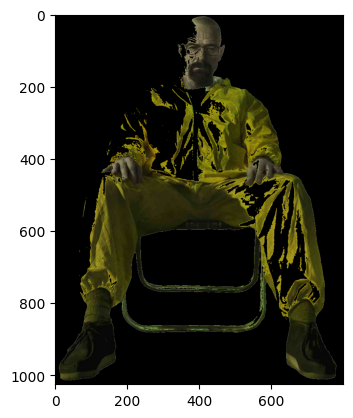

In [134]:
# img_separate = np.where(img_mask == 1, img1, 0)
img_separate = img1 * binary[..., None]
plt.imshow(img_separate)
print(img_separate.shape, img_separate.dtype)

### Composition
---

(2250, 3000, 3) uint8


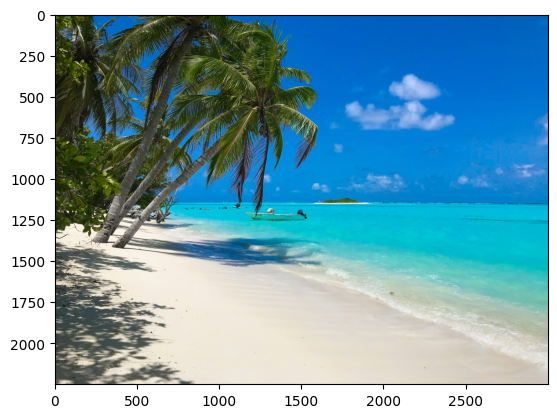

In [135]:
plt.imshow(img2_raw)
print(img2_raw.shape, img2_raw.dtype)

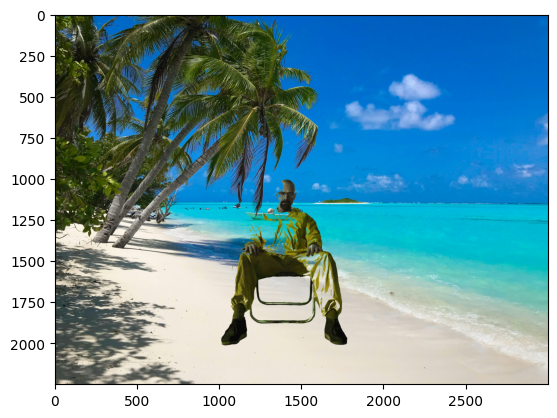

In [136]:
img_res = img2_raw.copy()
x, y = 1000, 1000

def compose(bg_img, fg_img, mask, y_pos, x_pos):
    h, w = fg_img.shape[:2]
    img_out = bg_img.copy()
    img_out[y_pos:y_pos+h, x_pos:x_pos+w, :] = (
        fg_img * mask[..., None] + 
        bg_img[y_pos:y_pos+h, x_pos:x_pos+w, :] * (1 - mask[..., None])
    )
    return img_out

img_res = compose(img2_raw, img1, binary, y, x)
plt.imshow(img_res)